In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("cleaned_ml_predictions.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1000, 10)


,Sample_ID,Actual_Microplastic_Count,Predicted_Microplastic_Count,Contamination_Risk_Score_Pct,Anomaly_Flag,Model_Confidence_Score,Model_Confidence_Pct,Prediction_Error,Absolute_Error,Error_Percentage
0,SMP-2026-0001,552,525,52.5,False,0.863,86.3,-27,27,4.891304
1,SMP-2026-0002,422,448,44.8,False,0.897,89.7,26,26,6.161137
2,SMP-2026-0003,39,41,4.1,False,0.861,86.1,2,2,5.128205
3,SMP-2026-0004,529,555,55.5,False,0.910,91.0,26,26,4.914934
4,SMP-2026-0005,87,95,9.5,False,0.960,96.0,8,8,9.195402


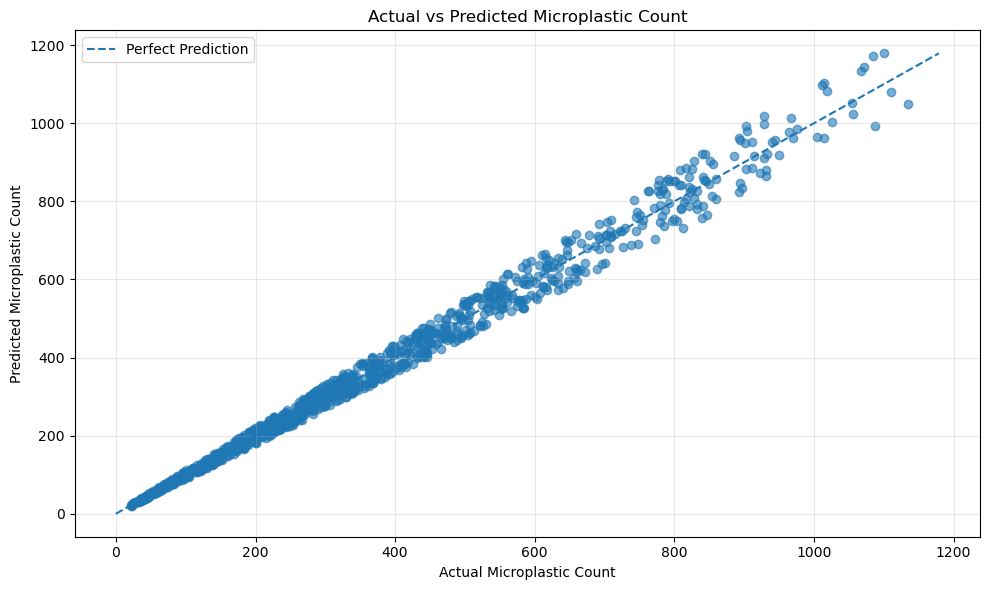

In [3]:
#Actual vs Predicted Microplastic Count
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Actual_Microplastic_Count"],
    df["Predicted_Microplastic_Count"],
    alpha=0.6
)

# Perfect prediction line
max_value = max(
    df["Actual_Microplastic_Count"].max(),
    df["Predicted_Microplastic_Count"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Microplastic Count")
plt.xlabel("Actual Microplastic Count")
plt.ylabel("Predicted Microplastic Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

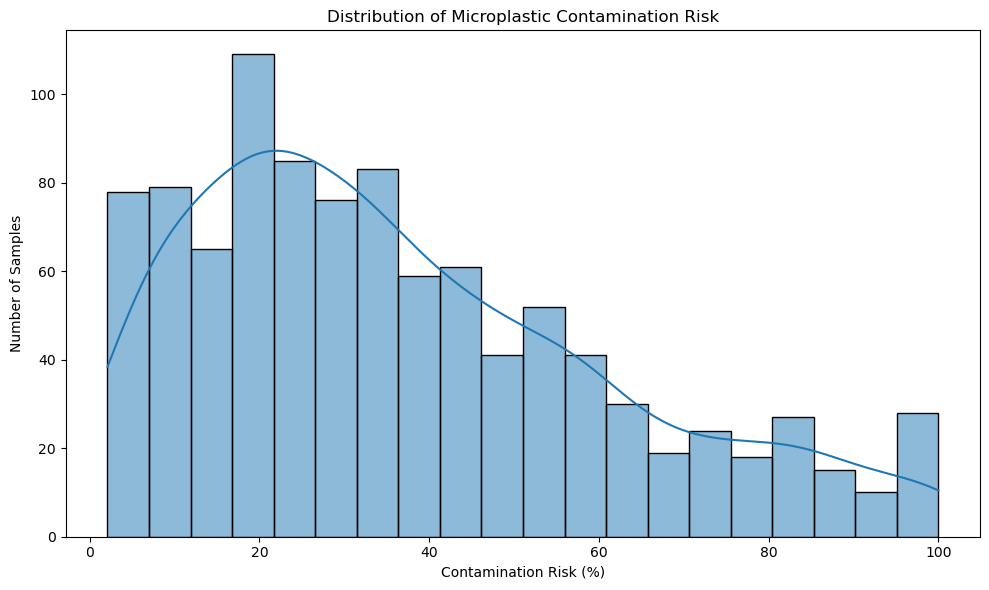

In [4]:
#Contamination Risk Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Contamination_Risk_Score_Pct"],
    bins=20,
    kde=True
)

plt.title("Distribution of Microplastic Contamination Risk")
plt.xlabel("Contamination Risk (%)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

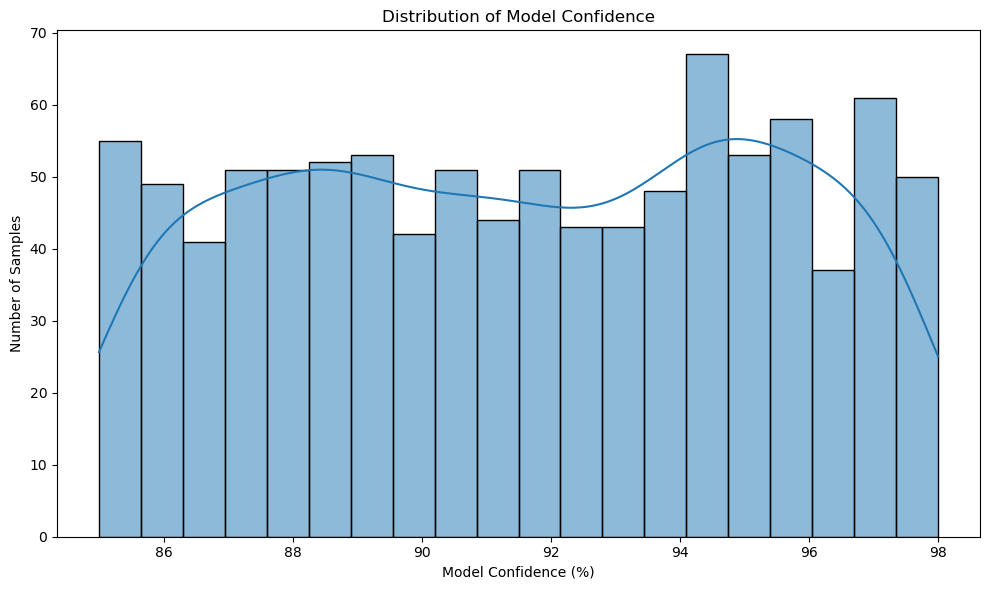

In [7]:
#Model Confidence Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Model_Confidence_Pct"],
    bins=20,
    kde=True
)

plt.title("Distribution of Model Confidence")
plt.xlabel("Model Confidence (%)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

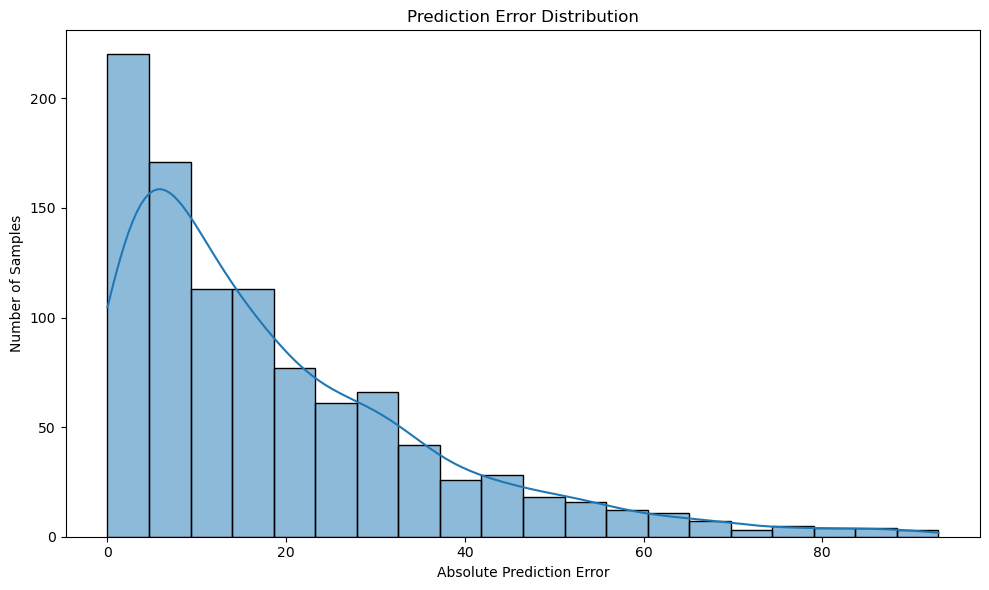

In [8]:
#Prediction Error Distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Absolute_Error"],
    bins=20,
    kde=True
)

plt.title("Prediction Error Distribution")
plt.xlabel("Absolute Prediction Error")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

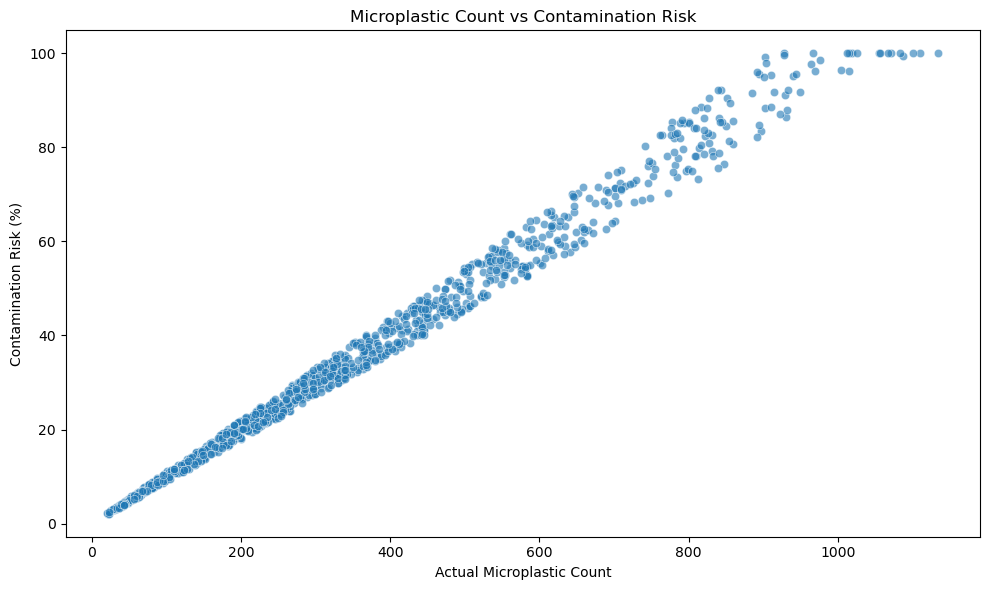

In [11]:
#Actual Count vs Contamination Risk
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Actual_Microplastic_Count",
    y="Contamination_Risk_Score_Pct",
    alpha=0.6
)

plt.title("Microplastic Count vs Contamination Risk")
plt.xlabel("Actual Microplastic Count")
plt.ylabel("Contamination Risk (%)")
plt.tight_layout()
plt.show()

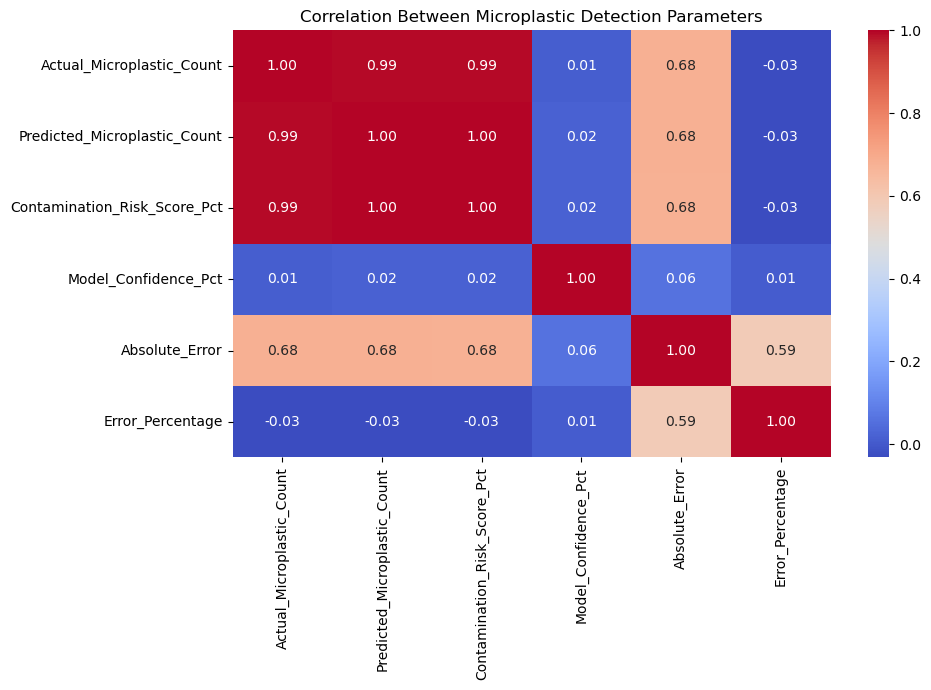

In [12]:
#Correlation Heatmap
plt.figure(figsize=(10, 7))

corr = df[
    [
        "Actual_Microplastic_Count",
        "Predicted_Microplastic_Count",
        "Contamination_Risk_Score_Pct",
        "Model_Confidence_Pct",
        "Absolute_Error",
        "Error_Percentage"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Microplastic Detection Parameters")
plt.tight_layout()
plt.show()